Utilizzando il dataset Wine replicare l'esercizio pratica con Iris:
* Applicare lo StandardScaler a tutte le feature
* Visualizzare tramite boxplot le feature originale e standarizzate
* Creare un grafico che mostri la Varianza Spiegata Singola e la Varianza Cumulativa.
* Misurare il tempo necessario per addestrare il modello K-Means (K=3 & random_seed=42) separatamente su:
    * il dataset standarizzato originale (X_std)
    * il dataset ridotto con PCA (X_pca)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

In [4]:
wine=load_wine()
X=pd.DataFrame(wine.data,columns=wine.feature_names)
y=pd.Series(wine.target,name='target')
print(X)

     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyan

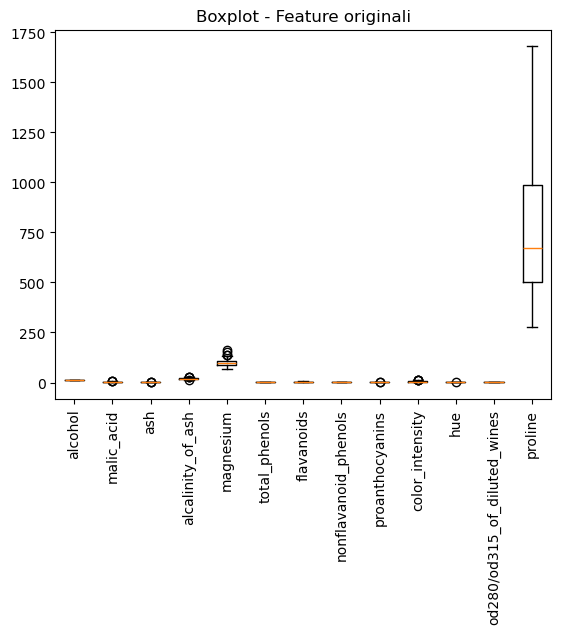

In [9]:
plt.boxplot(X)  #crea un boxplot per ogni feature
plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature originali")
plt.show()

Standarizzo

[ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17 -1.95536471e-16  9.44313292e-16 -4.17892936e-16
 -1.54059038e-15 -4.12903170e-16  1.39838203e-15  2.12688793e-15
 -6.98567296e-17] [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


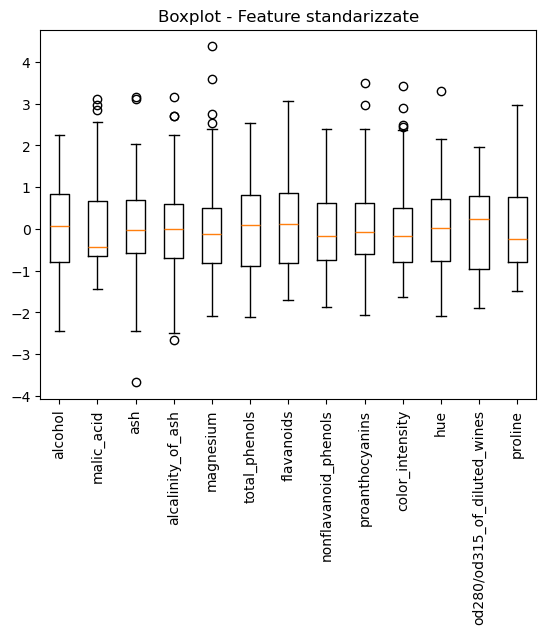

In [13]:
from matplotlib import axis

scaler=StandardScaler() #StandarScaler rende tutte le variabili (feature) comparabili
X_std=scaler.fit_transform(X)  #standarizzazione z-score

#StandarScaler porta la media a quasi 0 e la deviazione standard a 1
print(X_std.mean(axis=0), X_std.std(axis=0))

plt.boxplot(X_std)
plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature standarizzate")
plt.show()

 varianza: [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]
 varianza cumulativa: [0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


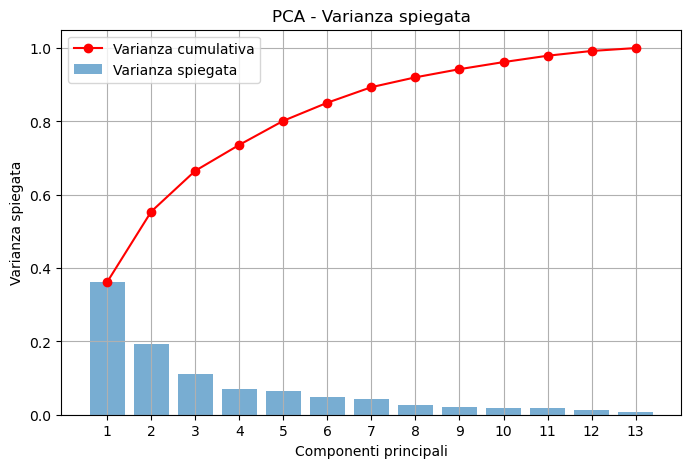

In [26]:
#dopo aver applicato la standarizzazione delle feature, posso applicare la PCA per una riduzione dimensionale

pca=PCA() #non ho definito n_components, quindi PCA calcola tante componenti quante sono le feature (4)
pca.fit(X_std) #trova PC1, PC2, PC3, PC4 con PC1 e PC2 con massima varianza

exp_var=pca.explained_variance_ratio_  #contiene quanta varianza del dataset spiega ogni componente PC
cum_var=np.cumsum(exp_var) #somma cumulativa
print(f" varianza: {exp_var}")
print(f" varianza cumulativa: {cum_var}")

#grafico

componenti = np.arange(1, len(exp_var) + 1)

plt.figure(figsize=(8,5))

# varianza singola
plt.bar(componenti, exp_var, alpha=0.6, label="Varianza spiegata")

# varianza cumulativa
plt.plot(componenti, cum_var, marker="o", color="red", label="Varianza cumulativa")

plt.xlabel("Componenti principali")
plt.ylabel("Varianza spiegata")
plt.title("PCA - Varianza spiegata")
plt.xticks(componenti)
plt.legend()
plt.grid()

plt.show()

con 5 feature (su 13) ho l'80% di varianza 

Misurare il tempo necessario per addestrare il modello K-Means (K=3 & random_seed=42) separatamente su:
    * il dataset standarizzato originale (X_std)
    * il dataset ridotto con PCA (X_pca)

CLUSTERING con KMeans

In [ ]:
import time
from sklearn.cluster import KMeans

t0_std=time.time()
kmeans_std = KMeans(n_clusters=3)
kmeans_std.fit(X_std)
t1_std=time.time()
t_std=t1_std-t0_std

#rifaccio riduzione dimensionale con PCA, nella precedente, non avendo definito n_components
#sono stati generati tanti pca quante le feature originali, in questo modo ho potuto verificare
#con con 5 pca si ottiene l' 80% di accuratezza, pertanto ora genero pca con n_components=5

pca = PCA(n_components=5)   #tengo solo 54 feature
X_pca = pca.fit_transform(X_std)

t0_pca=time.time()

kmeans = KMeans(n_clusters=3, random_state=42)  #genero 3 cluster
kmeans.fit(X_pca)

t1_pca=time.time()
t_pca=t1_pca-t0_pca

print (f"Tempo X_std= {t_std}")
print (f"Tempo X_pca= {t_pca}")





Tempo X_std= 0.010075569152832031
Tempo X_pca= 0.007978677749633789


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
